## Aid Received Analysis

This notebook will explore and analyse the aid entering Gaza since the beginning of the genocide in Gaza. It will also look at whether the volume and composition of humanitarian aid is primarily constrained by border access rather than supply availability.

The aid_events mart is used for analysis, which is based on data from: https://data.humdata.org/dataset/state-of-palestine-gaza-aid-truck-data

Weekly aggregation with a four week moving average is used to reduce daily volatility and to smooth the visualisations.

This page is currently still a work in progress.

### Hypothesis

Based on reports that aid trucks frequently queue at border crossings awaiting clearance, it is hypothesised that border access acts as a limiting factor for incoming aid.

Three specific hypotheses are tested:

- Total aid volume (measured in weekly pallet totals) increases during periods of ceasefire reletive to periods of active conflict.
- Food and water generally to be prioritised the most, followed by other important items such as: tents, bedding, medical items, hygiene items, clothes.
- Aid composition is skewed towards non-perishables during periods of reduced aid, due to trucks having to wait for long periods at the border.

### Data considerations and measurement limitations

A key methodological decision in this analysis is the use of number_of_trucks as the primary metric rather than the quantity field.

Although the data contains a quantity measure, it is recorded in multiple incompatible units (e.g. Pallets, Metric Ton, Ton, Piece, Cartons, Vehicles, etc.). While pallets represent the majority of entries, the presence of numerous other unit types prevent meaningful aggregation without introducing strong assumptions or unit conversions.

Although truck counts do not represent exact aid volume, they provide insight into distribution and a standardized, comparable measure across all aid events. The distribution of units in the dataset is shown below.

In [6]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("../dev.duckdb")

con.execute("""
SELECT units, SUM(quantity)::INT AS total_quantity
FROM main_mart.aid_events
GROUP BY units
ORDER BY SUM(quantity) DESC
""").df()

,units,total_quantity
0,Pallets,825933
1,MT,97056
2,Piece,73415
3,CTN,7920
4,Ton,6117
5,Truck,3871
6,None,3537
7,EACH,786
8,Tents,30
9,Vehicles,21


### Weekly trucks per cargo category

To analyse trends in aid deliveries over time per cargo category, the data is aggregated to a weekly level to reduce daily volatility and a rolling four week moving average is calculated to smooth the spikes and troughs.

The calculation is performed in two steps:

- calculate the weekly sum of trucks per category
- apply a window function to compute a rolling four week moving average (current week plus previous three weeks) within each catego

A key thing to note is that this looks at the number of trucks that contain categories of items, which may not correspond to the exact volume of aid that is entering.ry

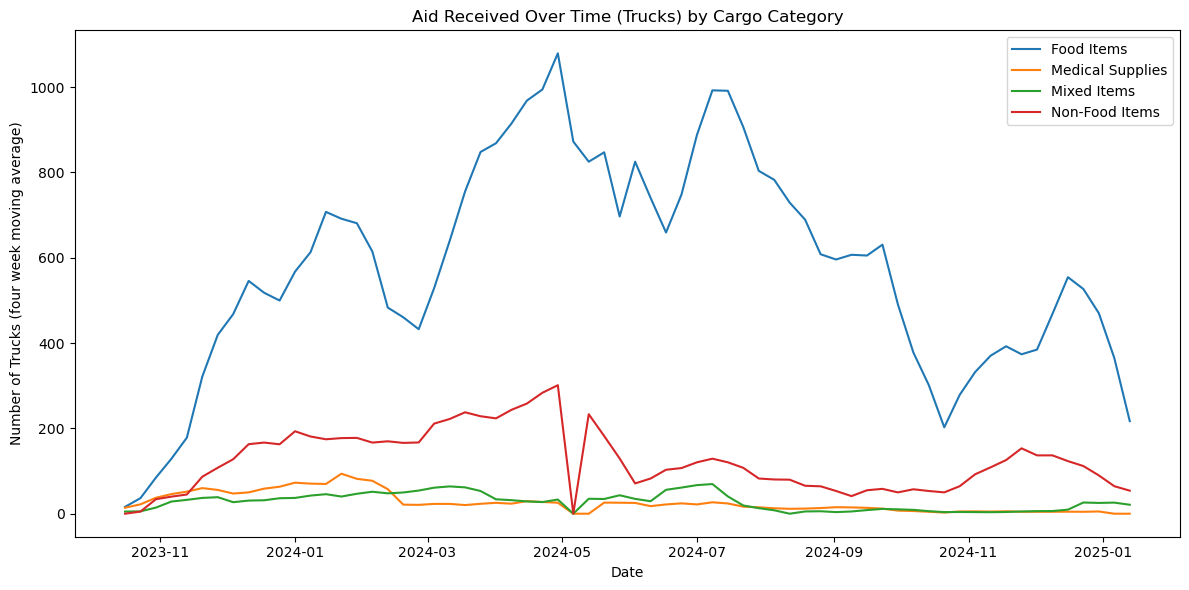

In [8]:
df = con.execute("""
WITH weekly_trucks_by_category AS (
    SELECT
        year,
        week_of_year,
        cargo_category,
        SUM(number_of_trucks) AS sum_of_trucks
    FROM main_mart.aid_events
    GROUP BY cargo_category, year, week_of_year
    ORDER BY year, week_of_year
)

SELECT
    year,
    week_of_year,
    cargo_category,
    sum_of_trucks,
    AVG(sum_of_trucks) OVER (PARTITION BY cargo_category ORDER BY year, week_of_year ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS ma_4w_trucks
FROM weekly_trucks_by_category
ORDER BY year, week_of_year


""").df()

df["week_start"] = pd.to_datetime(
    df["year"].astype(str) + "-W" + df["week_of_year"].astype(str) + "-1",
    format="%G-W%V-%u"
)

df_pivot = df.pivot(
    index="week_start",
    columns="cargo_category",
    values="ma_4w_trucks"
).fillna(0).sort_index()

plt.figure(figsize=(12,6))

for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], label=column)

plt.xlabel("Date")
plt.ylabel("Number of Trucks (four week moving average)")
plt.title("Aid Received Over Time (Trucks) by Cargo Category")
plt.legend()
plt.tight_layout()
plt.show()


### Weekly trucks per crossing

To analyse trends in aid deliveries over time per crossing, the data is aggregated to a weekly level to reduce daily volatility and a rolling four week moving average is calculated to smooth the spikes and troughs.

The calculation is performed in two steps:
- calculate the weekly sum of trucks per crossing
- apply a window function to compute a rolling four week moving average (current week plus previous three weeks) within each crossing

A key thing to note is that this looks at the number of trucks entering at each crossing, which may not correspond to the exact volume of aid that is entering.

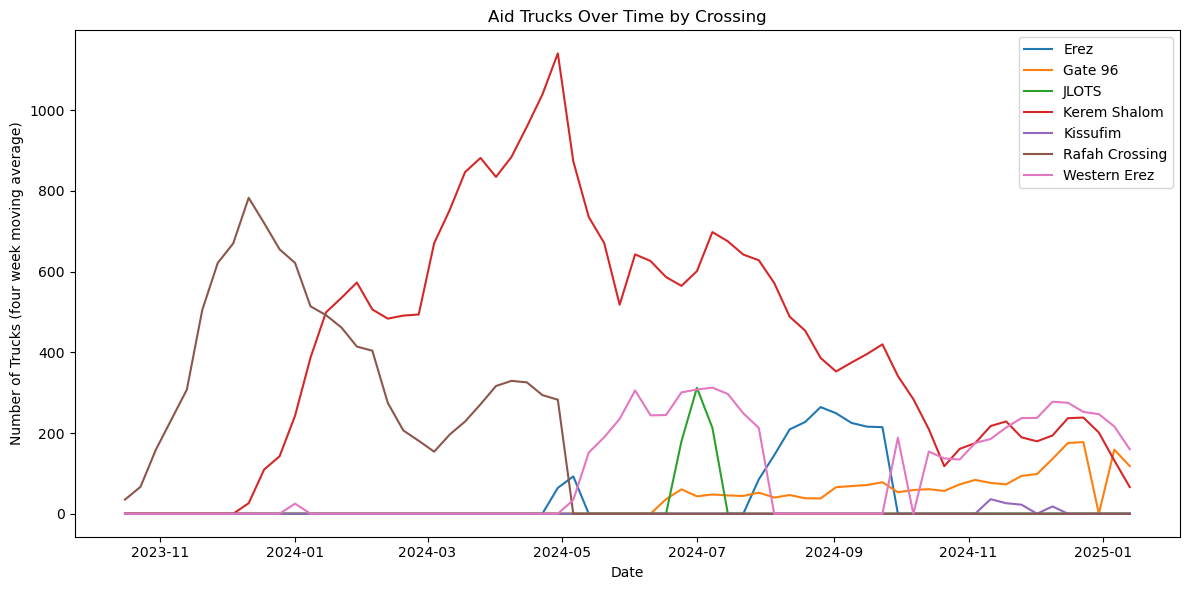

In [44]:
df = con.execute("""
WITH weekly_trucks_per_crossing AS (
    SELECT
        crossing_name,
        SUM(number_of_trucks) AS sum_of_trucks,
        year,
        week_of_year
    FROM main_mart.aid_events
    GROUP BY crossing_id, crossing_name, year, week_of_year
    ORDER BY year, week_of_year
)

SELECT
    crossing_name,
    sum_of_trucks,
    AVG(sum_of_trucks) OVER (PARTITION BY crossing_name ORDER BY year, week_of_year ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS ma_4w_trucks,
    year,
    week_of_year
FROM weekly_trucks_per_crossing
ORDER BY year, week_of_year
""").df()


df["week_start"] = pd.to_datetime(
    df["year"].astype(str) + "-W" + df["week_of_year"].astype(str) + "-1",
    format="%G-W%V-%u"
)

df_pivot = df.pivot(
    index="week_start",
    columns="crossing_name",
    values="ma_4w_trucks"
).fillna(0).sort_index()

plt.figure(figsize=(12,6))

for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], label=column)

plt.xlabel("Date")
plt.ylabel("Number of Trucks (four week moving average)")
plt.title("Aid Trucks Over Time by Crossing")
plt.legend()
plt.tight_layout()
plt.show()

Early on, Rafah Crossing was the most used crossing until Kerem Shalom saw significantly more use. The Rafah Crossing appears to be completely shut after May 2024.

Since

In [46]:
con.execute("""
    SELECT * FROM main_mart.aid_events
""").df()

,aid_event_id,date_id,full_date,year,week_of_year,number_of_trucks,items,cargo_category,quantity,units,donation_type,crossing_id,crossing_name,data_period,last_edited
0,72016,20241216,2024-12-16,2024,51,1,Pillow + Plastic Film,Non-Food Items,15,Pallets,Humanitarian - UN,b28e3bb3ffd57750a87b25c978bee897,Western Erez,Current Data (after Rafah Operation),2025-01-19 12:02:56
1,71919,20241215,2024-12-15,2024,50,1,Tarpaulins,Non-Food Items,40,Pallets,Humanitarian - UN,b28e3bb3ffd57750a87b25c978bee897,Western Erez,Current Data (after Rafah Operation),2025-01-19 12:03:03
2,69779,20241121,2024-11-21,2024,47,1,Floor Mattresses + Pillows Sleeping,Non-Food Items,17,Pallets,Humanitarian - UN,b28e3bb3ffd57750a87b25c978bee897,Western Erez,Current Data (after Rafah Operation),2025-01-19 12:04:13
3,67950,20241020,2024-10-20,2024,42,1,Flour,Food Items,16,Pallets,Humanitarian - UN,b28e3bb3ffd57750a87b25c978bee897,Western Erez,Current Data (after Rafah Operation),2025-01-19 12:05:19
4,67922,20241018,2024-10-18,2024,42,1,Flour,Food Items,17,MT,Humanitarian - UN,b28e3bb3ffd57750a87b25c978bee897,Western Erez,Current Data (after Rafah Operation),2025-01-19 12:05:19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50054,51976,20240704,2024-07-04,2024,27,1,Food Items,Food Items,16,Pallets,Humanitarian - INGO,02ee1aad92e50f4e614224d0c8e9ff0e,Kerem Shalom,Current Data (after Rafah Operation),2024-07-24 17:47:59
50055,51975,20240704,2024-07-04,2024,27,1,Food Items,Food Items,12,Pallets,Humanitarian - INGO,02ee1aad92e50f4e614224d0c8e9ff0e,Kerem Shalom,Current Data (after Rafah Operation),2024-07-24 17:47:59
50056,51974,20240704,2024-07-04,2024,27,1,Food Items,Food Items,18,Pallets,Humanitarian - INGO,02ee1aad92e50f4e614224d0c8e9ff0e,Kerem Shalom,Current Data (after Rafah Operation),2024-07-24 17:47:59
50057,51973,20240704,2024-07-04,2024,27,1,Food Items,Food Items,12,Pallets,Humanitarian - INGO,02ee1aad92e50f4e614224d0c8e9ff0e,Kerem Shalom,Current Data (after Rafah Operation),2024-07-24 17:47:59


In [ ]:
con.execute("""
SELECT crossing_id, crossing_name, COUNT(crossing_id), SUM(number_of_trucks)
FROM main_mart.aid_events
GROUP BY crossing_id, crossing_name
ORDER BY COUNT(crossing_id) DESC
""").df()

In [ ]:
con.execute("""
SELECT DISTINCT items, cargo_category, number_of_trucks, quantity, units
FROM main_mart.aid_events
WHERE units = 'Truck'
ORDER BY quantity DESC
""").df()